# Gráficas de litio desde datos Fortran

Este notebook **solo grafica** a partir de archivos Fortran guardados en `finite-diferences/`:

- `potential_litio_fortran.dat`
- `funciones_radiales_litio_fortran.dat`
- `energias_litio_fortran.dat`

No recalcula espectro ni potencial en Python.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

hartree_to_ev = 27.211386245988
base = Path('.')
df_dir = base / 'finite-diferences'

pot_file = df_dir / 'potential_litio_fortran.dat'
wf_file = df_dir / 'funciones_radiales_litio_fortran.dat'
ene_file = df_dir / 'energias_litio_fortran.dat'

assert pot_file.exists(), f'No existe {pot_file}'
assert wf_file.exists(), f'No existe {wf_file}'
assert ene_file.exists(), f'No existe {ene_file}'

pot = np.loadtxt(pot_file, comments='#')
wf = np.loadtxt(wf_file, comments='#')

# Si energias_litio_fortran.dat tiene estado,l,E(Ha),E(eV), usamos la ultima columna.
energies = {}
with open(ene_file, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip().startswith('#') or not line.strip():
            continue
        parts = line.split()
        state = parts[0]
        e_ev = float(parts[-1])
        energies[state] = e_ev

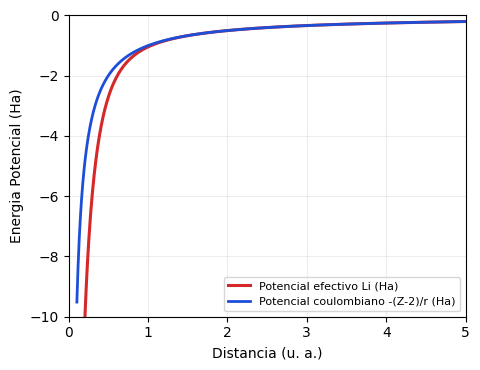

In [3]:
# Columnas: r, Vc(Ha), Veff(Ha)
r = pot[:, 0]
vc_ha = pot[:, 1]
veff_ha = pot[:, 2]

# Escala en Hartree y aspecto similar al documento
mask = (r >= 0.10) & (r <= 5.0)

fig, ax = plt.subplots(figsize=(4.9, 3.8))
ax.plot(
    r[mask], veff_ha[mask],
    lw=2.2, color='#d62828', label='Potencial efectivo Li (Ha)'
)
ax.plot(
    r[mask], vc_ha[mask],
    lw=2.0, color='#1d4ed8', label='Potencial coulombiano -(Z-2)/r (Ha)'
)
ax.set_xlim(0.0, 5.0)
ax.set_ylim(-10.0, 0.0)
ax.set_xlabel('Distancia (u. a.)')
ax.set_ylabel('Energia Potencial (Ha)')
ax.grid(alpha=0.22)
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

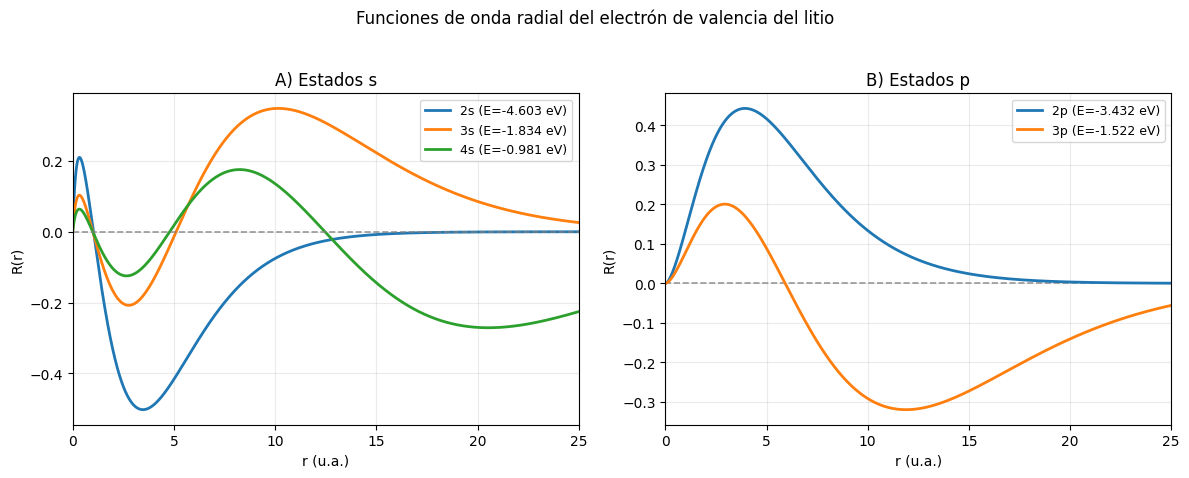

In [4]:
# Columnas: r, R_2s, R_3s, R_4s, R_2p, R_3p
rw = wf[:, 0]
r2s, r3s, r4s, r2p, r3p = wf[:, 1], wf[:, 2], wf[:, 3], wf[:, 4], wf[:, 5]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True)

axes[0].plot(rw, r2s, lw=2.0, label=f"2s (E={energies.get('2s', np.nan):.3f} eV)")
axes[0].plot(rw, r3s, lw=2.0, label=f"3s (E={energies.get('3s', np.nan):.3f} eV)")
axes[0].plot(rw, r4s, lw=2.0, label=f"4s (E={energies.get('4s', np.nan):.3f} eV)")
axes[0].set_xlim(0.0, 25.0)
axes[0].set_xlabel('r (u.a.)')
axes[0].set_ylabel('R(r)')
axes[0].set_title('A) Estados s')
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=9)
axes[0].axhline(0.0, color='gray', lw=1.2, ls='--', alpha=0.8)
axes[1].axhline(0.0, color='gray', lw=1.2, ls='--', alpha=0.8)

axes[1].plot(rw, r2p, lw=2.0, label=f"2p (E={energies.get('2p', np.nan):.3f} eV)")
axes[1].plot(rw, r3p, lw=2.0, label=f"3p (E={energies.get('3p', np.nan):.3f} eV)")
axes[1].set_xlim(0.0, 25.0)
axes[1].set_xlabel('r (u.a.)')
axes[1].set_ylabel('R(r)')
axes[1].set_title('B) Estados p')
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=9)

plt.suptitle('Funciones de onda radial del electrón de valencia del litio', y=1.03)
plt.tight_layout()
plt.show()

## Comparacion Fortran vs C++ vs Python desde DAT

Esta seccion usa exclusivamente `comparacion_lenguajes.dat` para mostrar:

- tiempo de ejecucion
- energia 2s
- error relativo
- iteraciones variacionales
- numero de estados extraidos (s y p)

Tabla comparativa (desde comparacion_lenguajes.dat)
language | time_s | var_iter | e2s_ev | err_rel_ion | err_rel_2s | n_s | n_p
fortran |  2.14360 |        3 |  -4.6031 | 4.715498e-04 | 1.460004e-01 |   3 |   2
    cpp |  1.24008 |        3 |  -4.6031 | 4.716259e-04 | 1.460004e-01 |   3 |   2
     py | 55.88454 |        3 |  -4.6031 | 4.716259e-04 | 1.460004e-01 |   3 |   2


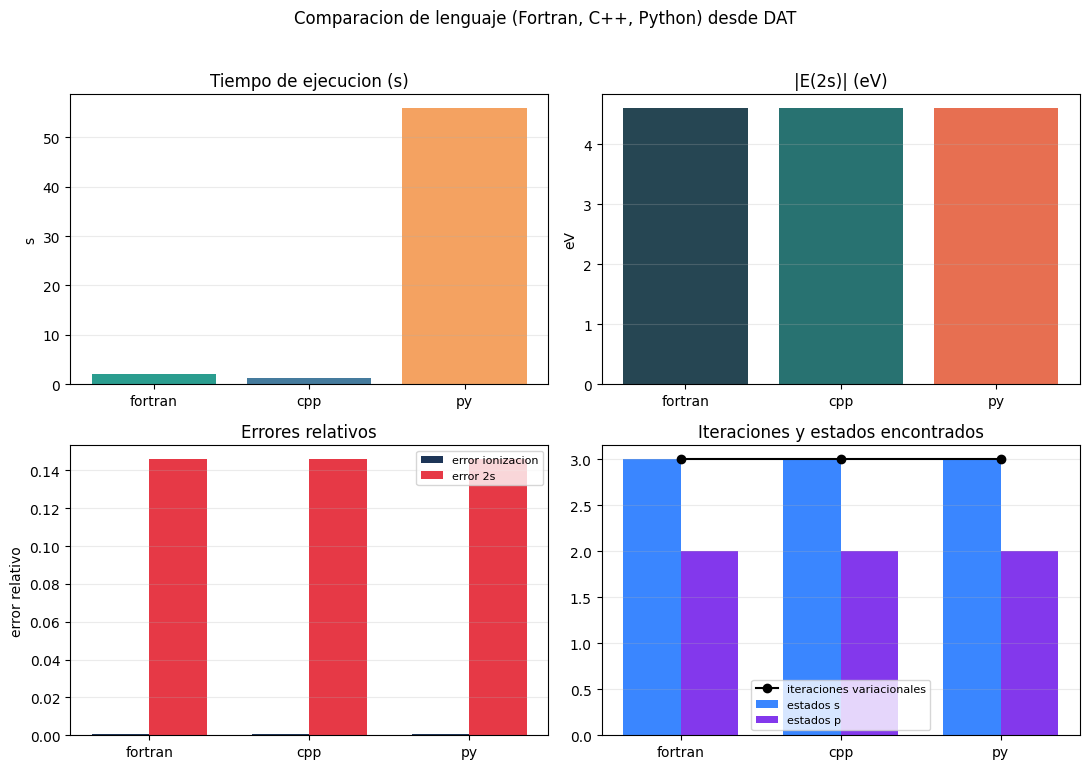

In [5]:
cmp_file = base / 'comparacion_lenguajes.dat'
assert cmp_file.exists(), f'No existe {cmp_file}'

cmp = np.genfromtxt(cmp_file, comments='#', dtype=None, encoding='utf-8')
if cmp.ndim == 0:
    cmp = np.array([cmp], dtype=cmp.dtype)

langs = cmp['f0']
time_s = cmp['f1'].astype(float)
var_iter = cmp['f2'].astype(int)
e2s_ev = cmp['f5'].astype(float)
err_ion = cmp['f6'].astype(float)
err_2s = cmp['f7'].astype(float)
n_s = cmp['f8'].astype(int)
n_p = cmp['f9'].astype(int)

print('Tabla comparativa (desde comparacion_lenguajes.dat)')
print('language | time_s | var_iter | e2s_ev | err_rel_ion | err_rel_2s | n_s | n_p')
for i in range(len(langs)):
    print(f"{langs[i]:>7} | {time_s[i]:8.5f} | {var_iter[i]:8d} | {e2s_ev[i]:8.4f} | {err_ion[i]:11.6e} | {err_2s[i]:11.6e} | {n_s[i]:3d} | {n_p[i]:3d}")

x = np.arange(len(langs))
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))

axes[0, 0].bar(x, time_s, color=['#2a9d8f', '#457b9d', '#f4a261'])
axes[0, 0].set_xticks(x, langs)
axes[0, 0].set_title('Tiempo de ejecucion (s)')
axes[0, 0].set_ylabel('s')
axes[0, 0].grid(axis='y', alpha=0.25)

axes[0, 1].bar(x, np.abs(e2s_ev), color=['#264653', '#287271', '#e76f51'])
axes[0, 1].set_xticks(x, langs)
axes[0, 1].set_title('|E(2s)| (eV)')
axes[0, 1].set_ylabel('eV')
axes[0, 1].grid(axis='y', alpha=0.25)

width = 0.36
axes[1, 0].bar(x - width / 2, err_ion, width=width, label='error ionizacion', color='#1d3557')
axes[1, 0].bar(x + width / 2, err_2s, width=width, label='error 2s', color='#e63946')
axes[1, 0].set_xticks(x, langs)
axes[1, 0].set_title('Errores relativos')
axes[1, 0].set_ylabel('error relativo')
axes[1, 0].grid(axis='y', alpha=0.25)
axes[1, 0].legend(fontsize=8)

axes[1, 1].bar(x - width / 2, n_s, width=width, label='estados s', color='#3a86ff')
axes[1, 1].bar(x + width / 2, n_p, width=width, label='estados p', color='#8338ec')
axes[1, 1].plot(x, var_iter, marker='o', color='black', label='iteraciones variacionales')
axes[1, 1].set_xticks(x, langs)
axes[1, 1].set_title('Iteraciones y estados encontrados')
axes[1, 1].grid(axis='y', alpha=0.25)
axes[1, 1].legend(fontsize=8)

plt.suptitle('Comparacion de lenguaje (Fortran, C++, Python) desde DAT', y=1.02)
plt.tight_layout()
plt.show()

### Comparación energías leonardo

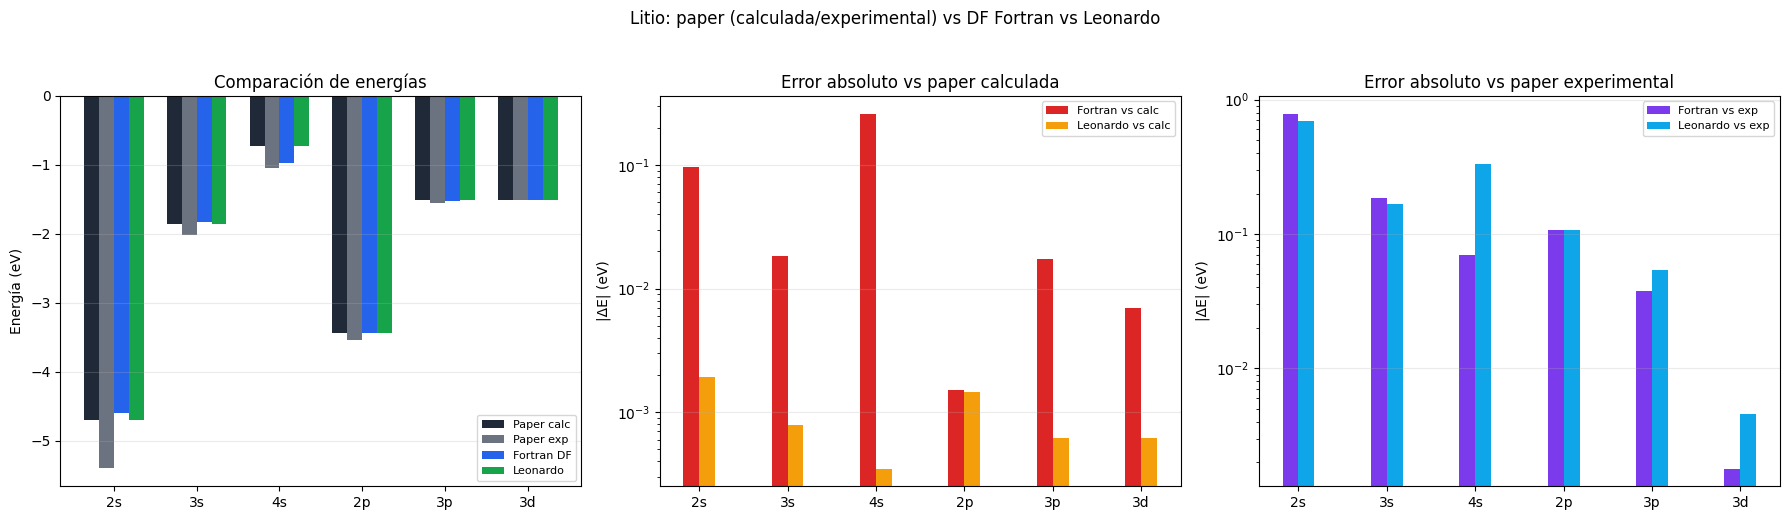

          MAE_vs_calc_eV  MAE_vs_exp_eV
Fortran         0.066850       0.198215
Leonardo        0.000961       0.225273


In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Rutas
base = Path("finite-diferences")
f_paper = base / "energias_paper.dat"
f_fortran = base / "energias_litio_fortran.dat"
f_leonardo = base / "energias_litio_leonardo.dat"

# ---------- Carga de datos ----------
# paper: estado l E_calc(Ha) E_calc(eV) E_exp(Ha) E_exp(eV) E_H(Ha) E_H(eV)
paper = pd.read_csv(
    f_paper,
    comment="#",
    sep=r"\s+",
    header=None,
    names=[
        "Estado", "l",
        "E_calc_Ha", "E_calc_eV",
        "E_exp_Ha", "E_exp_eV",
        "E_H_Ha", "E_H_eV"
    ],
)

# fortran / leonardo: estado l E(Ha) E(eV)
fortran = pd.read_csv(
    f_fortran,
    comment="#",
    sep=r"\s+",
    header=None,
    names=["Estado", "l", "E_Ha_fortran", "E_eV_fortran"],
)

leonardo = pd.read_csv(
    f_leonardo,
    comment="#",
    sep=r"\s+",
    header=None,
    names=["Estado", "l", "E_Ha_leonardo", "E_eV_leonardo"],
)

# Solo estados comparables con paper (intersección)
df = (
    paper[["Estado", "E_calc_eV", "E_exp_eV"]]
    .merge(fortran[["Estado", "E_eV_fortran"]], on="Estado", how="inner")
    .merge(leonardo[["Estado", "E_eV_leonardo"]], on="Estado", how="inner")
)

# Orden físico deseado
orden = ["2s", "3s", "4s", "2p", "3p", "3d", "4p", "4d"]
df["Estado"] = pd.Categorical(df["Estado"], categories=orden, ordered=True)
df = df.sort_values("Estado").reset_index(drop=True)

# Errores (respecto a paper calculada y experimental)
df["abs_err_fortran_vs_calc"] = np.abs(df["E_eV_fortran"] - df["E_calc_eV"])
df["abs_err_leonardo_vs_calc"] = np.abs(df["E_eV_leonardo"] - df["E_calc_eV"])
df["abs_err_fortran_vs_exp"] = np.abs(df["E_eV_fortran"] - df["E_exp_eV"])
df["abs_err_leonardo_vs_exp"] = np.abs(df["E_eV_leonardo"] - df["E_exp_eV"])

# ---------- Gráficos ----------
x = np.arange(len(df))
w = 0.18

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Energías
ax[0].bar(x - 1.5*w, df["E_calc_eV"], width=w, label="Paper calc", color="#1f2937")
ax[0].bar(x - 0.5*w, df["E_exp_eV"],  width=w, label="Paper exp",  color="#6b7280")
ax[0].bar(x + 0.5*w, df["E_eV_fortran"], width=w, label="Fortran DF", color="#2563eb")
ax[0].bar(x + 1.5*w, df["E_eV_leonardo"], width=w, label="Leonardo", color="#16a34a")
ax[0].set_xticks(x)
ax[0].set_xticklabels(df["Estado"])
ax[0].set_ylabel("Energía (eV)")
ax[0].set_title("Comparación de energías")
ax[0].grid(axis="y", alpha=0.25)
ax[0].legend(fontsize=8)

# Panel 2: error absoluto vs E_calc
ax[1].bar(x - w/2, df["abs_err_fortran_vs_calc"], width=w, label="Fortran vs calc", color="#dc2626")
ax[1].bar(x + w/2, df["abs_err_leonardo_vs_calc"], width=w, label="Leonardo vs calc", color="#f59e0b")
ax[1].set_xticks(x)
ax[1].set_xticklabels(df["Estado"])
ax[1].set_yscale("log")
ax[1].set_ylabel("|ΔE| (eV)")
ax[1].set_title("Error absoluto vs paper calculada")
ax[1].grid(axis="y", alpha=0.25)
ax[1].legend(fontsize=8)

# Panel 3: error absoluto vs E_exp
ax[2].bar(x - w/2, df["abs_err_fortran_vs_exp"], width=w, label="Fortran vs exp", color="#7c3aed")
ax[2].bar(x + w/2, df["abs_err_leonardo_vs_exp"], width=w, label="Leonardo vs exp", color="#0ea5e9")
ax[2].set_xticks(x)
ax[2].set_xticklabels(df["Estado"])
ax[2].set_yscale("log")
ax[2].set_ylabel("|ΔE| (eV)")
ax[2].set_title("Error absoluto vs paper experimental")
ax[2].grid(axis="y", alpha=0.25)
ax[2].legend(fontsize=8)

plt.suptitle("Litio: paper (calculada/experimental) vs DF Fortran vs Leonardo", y=1.03)
plt.tight_layout()
plt.show()

# Resumen numérico opcional
mae = pd.DataFrame({
    "MAE_vs_calc_eV": [
        df["abs_err_fortran_vs_calc"].mean(),
        df["abs_err_leonardo_vs_calc"].mean(),
    ],
    "MAE_vs_exp_eV": [
        df["abs_err_fortran_vs_exp"].mean(),
        df["abs_err_leonardo_vs_exp"].mean(),
    ]
}, index=["Fortran", "Leonardo"])
print(mae)

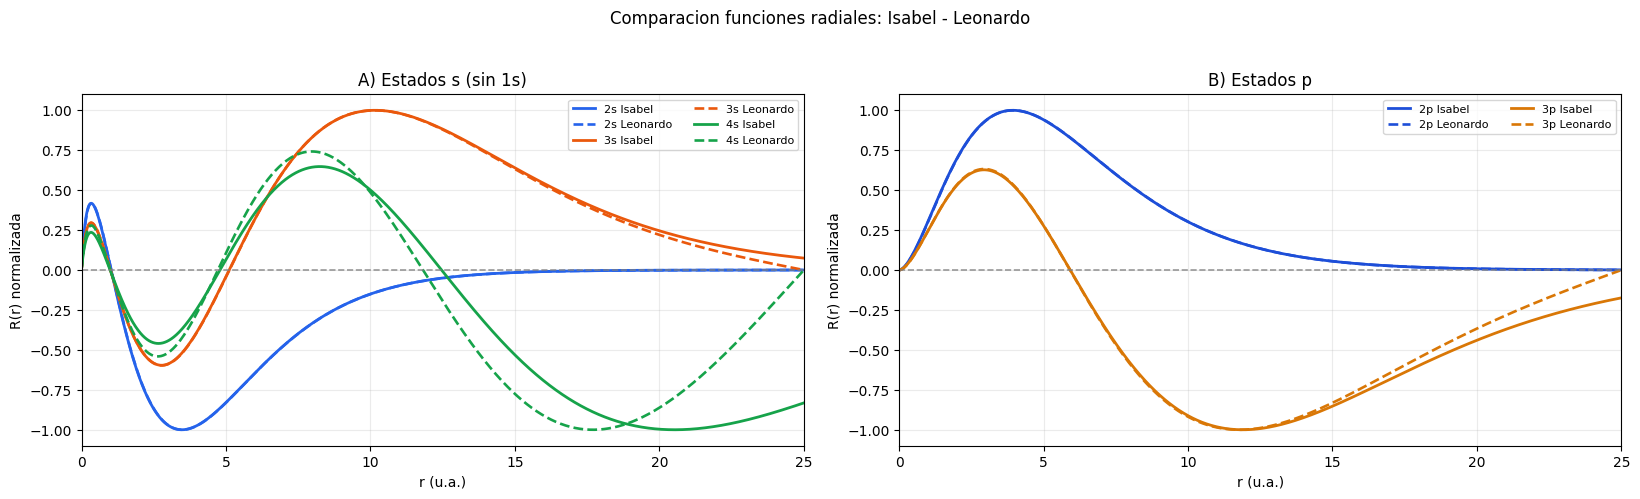

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Archivos
base = Path("finite-diferences")
f_fortran = base / "funciones_radiales_litio_fortran.dat"
f_leonardo = base / "funciones_radiales_litio_fortran_leonardo.DAT"

# ---------- Carga ----------
# Fortran: # r  R_2s R_3s R_4s R_2p R_3p R_3d
wf_f = np.loadtxt(f_fortran, comments="#")
r_f = wf_f[:, 0]
R_f = {
    "2s": wf_f[:, 1],
    "3s": wf_f[:, 2],
    "4s": wf_f[:, 3],
    "2p": wf_f[:, 4],
    "3p": wf_f[:, 5],
    "3d": wf_f[:, 6],
}

# Leonardo: r psi_1 psi_2 psi_3 psi_4 psi_5 psi_6 psi_7
# psi_1 = 1s (NO se usa)
wf_l = np.genfromtxt(f_leonardo, skip_header=1)
r_l = wf_l[:, 0]
R_l = {
    "2s": wf_l[:, 2],  # psi_2
    "3s": wf_l[:, 3],  # psi_3
    "4s": wf_l[:, 4],  # psi_4
    "2p": wf_l[:, 5],  # psi_5
    "3p": wf_l[:, 6],  # psi_6
    "3d": wf_l[:, 7],  # psi_7
}

# ---------- Utilidades ----------
def normalize_in_window(r, y, rmin=0.0, rmax=25.0):
    m = (r >= rmin) & (r <= rmax)
    if not np.any(m):
        return y
    scale = np.max(np.abs(y[m]))
    if not np.isfinite(scale) or scale <= 0.0:
        return y
    return y / scale

def phase_align(y_ref, y_cmp):
    # El signo global de una autofuncion es arbitrario.
    # Si la correlacion es negativa, se invierte para comparar forma.
    corr = np.nansum(y_ref * y_cmp)
    return -y_cmp if corr < 0 else y_cmp

def interp_to_ref(r_ref, r_src, y_src):
    return np.interp(r_ref, r_src, y_src)

# ---------- Preparacion ----------
states_s = ["2s", "3s", "4s"]
states_p = ["2p", "3p"]
states_d = ["3d"]

colors = {
    "2s": "#2563eb", "3s": "#ea580c", "4s": "#16a34a",
    "2p": "#1d4ed8", "3p": "#d97706",
    "3d": "#7c3aed",
}

rmin, rmax = 0.0, 25.0
mask_f = (r_f >= rmin) & (r_f <= rmax)
mask_l = (r_l >= rmin) & (r_l <= rmax)

fig, axes = plt.subplots(1, 2, figsize=(16.5, 4.8), sharex=False)

# Panel A: estados s
for st in states_s:
    y_f = normalize_in_window(r_f, R_f[st], rmin, rmax)
    y_l = normalize_in_window(r_l, R_l[st], rmin, rmax)

    # Alinear fase con referencia Fortran en malla de Fortran
    y_l_on_f = interp_to_ref(r_f, r_l, y_l)
    y_l = phase_align(y_f, y_l_on_f)
    # y_l ahora esta en malla de Fortran; para dibujar en malla de Leonardo:
    y_l_plot = interp_to_ref(r_l, r_f, y_l)

    axes[0].plot(r_f[mask_f], y_f[mask_f], color=colors[st], lw=2.0, label=f"{st} Isabel")
    axes[0].plot(r_l[mask_l], y_l_plot[mask_l], color=colors[st], lw=1.9, ls="--", label=f"{st} Leonardo")

axes[0].set_xlim(rmin, rmax)
axes[0].set_ylim(-1.1, 1.1)
axes[0].set_title("A) Estados s (sin 1s)")
axes[0].set_xlabel("r (u.a.)")
axes[0].set_ylabel("R(r) normalizada")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8, ncol=2)
axes[0].axhline(0.0, color='gray', lw=1.2, ls='--', alpha=0.8)


# Panel B: estados p
for st in states_p:
    y_f = normalize_in_window(r_f, R_f[st], rmin, rmax)
    y_l = normalize_in_window(r_l, R_l[st], rmin, rmax)

    y_l_on_f = interp_to_ref(r_f, r_l, y_l)
    y_l = phase_align(y_f, y_l_on_f)
    y_l_plot = interp_to_ref(r_l, r_f, y_l)

    axes[1].plot(r_f[mask_f], y_f[mask_f], color=colors[st], lw=2.0, label=f"{st} Isabel")
    axes[1].plot(r_l[mask_l], y_l_plot[mask_l], color=colors[st], lw=1.9, ls="--", label=f"{st} Leonardo")

axes[1].set_xlim(rmin, rmax)
axes[1].set_ylim(-1.1, 1.1)
axes[1].set_title("B) Estados p")
axes[1].set_xlabel("r (u.a.)")
axes[1].set_ylabel("R(r) normalizada")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8, ncol=2)
axes[1].axhline(0.0, color='gray', lw=1.2, ls='--', alpha=0.8)

plt.suptitle("Comparacion funciones radiales: Isabel - Leonardo", y=1.03)
plt.tight_layout()
plt.show()